# 3장 평가

# 1. 정확도
단순한 알고리즘으로 예측을 하더라도 데이터의 구성에 따라 정확도 결과가 높게 나올 수 있음
> 즉, 정확도를 평가 지표로 사용할 때는 신중하도록

In [1]:
#1.1 단순한 Classifier
import numpy as np
from sklearn.base import BaseEstimator

class MyDummyClassifier(BaseEstimator):
    # fit() 메서드는 아무것도 학습하지 않음.
    def fit(self, X, y=None):
        pass

    # predict() 메서드는 단순히 Sex 피처가 1이면 0, 그렇지 않으면 1로 예측함.
    def predict(self, X):
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i] == 1:
                pred[i] = 0
            else:
                pred[i] = 1
        return pred

In [4]:
#1.1.2 데이터 가공 후 학습/예측/평가
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# --- 1. 직접 정의해야 하는 transform_features 함수 ---
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

def format_features(df):
    df['Cabin'] = df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

# --- 2. MyDummyClassifier 클래스 정의 ---
class MyDummyClassifier(BaseEstimator):
    def fit(self, X, y=None):
        pass

    def predict(self, X):
        pred = np.zeros((X.shape[0], 1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i] == 1:
                pred[i] = 0
            else:
                pred[i] = 1
        return pred

# --- 3. 데이터 가공 및 실행 ---
titanic_df = pd.read_csv('./titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

# 여기서 직접 만든 함수를 호출합니다.
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=0)

# 학습/예측/평가
myclf = MyDummyClassifier() 
myclf.fit(X_train, y_train)

mypredictions = myclf.predict(X_test)
print('Dummy Classifier의 정확도는: {0:.4f}'.format(accuracy_score(y_test, mypredictions)))

Dummy Classifier의 정확도는: 0.7877


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25100\686522035.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25100\686522035.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

#### 1.2 아무것도 하지 않고 무조건 특정한 결과로 찍어도 데이터 분포도가 균일하지 않은 경우 높은 수치가 나타날 수 있는 것이 정확도 평가 지표의 맹점

In [6]:
#1.2.1 불균형한 데이터 세트와 Dummy Classifier를 생성
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

class MyFakeClassifier(BaseEstimator):
    def fit(self, X, y):
        pass
    
    # 입력값으로 들어오는 X 데이터 세트의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

# 사이킷런의 내장 데이터 세트인 load_digits()를 이용해 MNIST 데이터 로딩
digits = load_digits()

# digits 번호가 7번이면 True이고 이를 astype(int)로 1로 변환, 7번이 아니면 False이고 0으로 변환.
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)

# 불균형한 데이터 세트 성능 확인
print('레이블 테스트 세트 크기 :', y_test.shape)
print('테스트 세트 레이블 0 과 1의 분포 :')
print(pd.Series(y_test).value_counts())

# Dummy Classifier로 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 했을 때의 정확도: {:.3f}'.format(accuracy_score(y_test, fakepred)))

레이블 테스트 세트 크기 : (450,)
테스트 세트 레이블 0 과 1의 분포 :
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 했을 때의 정확도: 0.900


In [7]:
#1.2.2 y_test의 데이터 분포도를 확인하고 MyFakeClassifier를 이용해 예측과 평가를 수행
# 불균형한 레이블 데이터 분포도 확인
print('레이블 테스트 세트 크기: ', y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

#Dummy Classifier로 학습/예측/정확도 평가
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test,fakepred)))

레이블 테스트 세트 크기:  (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


In [ ]:
#1. 시사하는 바: 정확도 =/= 성능
- 단순히 모든 것을 0으로만 예측해도 MyFakeClassifier의 정확도가 90%로 유수의 ML알고리즘과 어깨를 겨룰 수 있는 것
- 정확도 평가 지표는 불균형한 레이블 데이터 세트에서는 성능 수치로 사용돼서는 안된다

# 2. 오차 행렬

### 2.1 confusion Matrix : 예측 성능 지표를 오차 행렬로 표현

In [9]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, fakepred)

array([[405,   0],
       [ 45,   0]])

# 정확도 vs 정밀도 vs 재현율
- 정확도: (TN + TP)/(TN + FP + FN + TP)
- 정밀도: TP/(FP + TP)
- 재현율: TP/(FN + TP)

# 3. 정밀도와 재현율

### 3.1 정밀도와 재현율 개요

#### 3.1.1 중요한 경우
- 재현율이 중요 지표인 경우: P를 N으로 잘못 판단되었을 경우 업무상 큰 영향을 주는 경우
- 정밀도가 중요 지표인 경우: N을 P로 ~

#### 3.1.2 재현율, 정밀도 구하기

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    
    print('오차 행렬')
    print(confusion)
    # .format() 끝에 recall을 꼭 추가해 주세요!
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

#### 3.1.3 로지스틱 회귀로 분류를 수행

In [16]:
import pandas as pd  
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할.
titanic_df = pd.read_csv('./titanic_train.csv') 
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1) 
X_titanic_df = transform_features(X_titanic_df) 

# train_test_split 인자 전달 방식 수정
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df, 
                                                    test_size=0.20, random_state=11)

lr_clf = LogisticRegression(solver='liblinear') # 로지스틱 회귀 모델 생성
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)

# 이전에 정의한 평가 함수 호출
get_clf_eval(y_test, pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25100\686522035.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_25100\686522035.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

### 3.2 정밀도/재현율 트레이드오프

#### 3.2.1 predict_proba() 메서드를 수행한 뒤 반환 값을 확인하고 predict() 메서드의 결과와 비교

In [19]:
pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

print('pred_proba() 결과 Shape : {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n', pred_proba_result[:3])

pred_proba() 결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.44935226 0.55064774]
 [0.86335512 0.13664488]
 [0.86429644 0.13570356]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935226 0.55064774 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429644 0.13570356 0.        ]]


#### 3.2.2 Binarizer 클래스

In [20]:
from sklearn.preprocessing import Binarizer

X = [[1,-1,2],
     [2,0,0],
     [0,1.1,1.2]]
#X의 개별 원소들이 threshold 값보다 같거나 작으면 0을, 크면 1을 반환
binarizer = Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


#### 3.2.3 최종 예측값에 대해 get_clf_eval()를 적용하여 평가 지표를 출력

In [21]:
from sklearn.preprocessing import Binarizer

custom_threshold = 0.5

pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


#### 3.2.4 임계값을 0.4로 낮추었을 경우

In [22]:
#Binarizer의 threshold 설정값을 0.4로 설정. 즉 분류 결정 임계값을 0.5에서 0.4로 낮춤
custom_threshold = 0.4
pred_proba_1 = pred_proba[:,1].reshape(-1,1)
binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


#### 3.2.5 임계값을 조금씩 높였을 경우

In [25]:
#테스트를 수행할 모든 임계값을 리스트 객체로 저장
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    #thresholds list 객체 내의 값을 차례로 iteration하면서 evaluation 수행
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:',custom_threshold)
        get_clf_eval(y_test, custom_predict)

get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1,1), thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


#### 3.2.6 임계값별 정밀도와 재현율 feat. precision_recall_curve()

In [26]:
import numpy as np
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일 때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 실제값 데이터 세트와 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)
print('반환된 분류 결정 임곗값 배열의 Shape: ', thresholds.shape)

# 반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 Step으로 추출.
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임계값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값: ', np.round(thresholds[thr_index], 2))

# 15 step 단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임계값별 정밀도: ', np.round(precisions[thr_index], 3))
print('샘플 임계값별 재현율: ', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape:  (165,)
샘플 추출을 위한 임계값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값:  [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임계값별 정밀도:  [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임계값별 재현율:  [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


#### 3.2.7 시각화

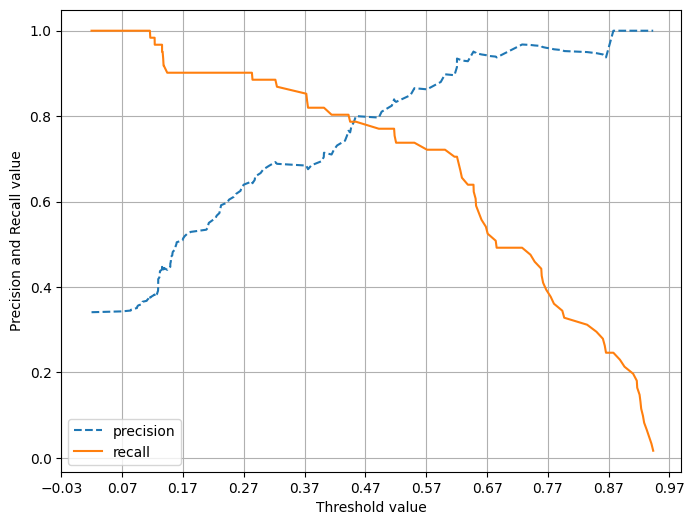

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)
    
    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')
    
    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    
    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

# 4. F1 스코어

#### F1 스코어 정의
: 정밀도와 재현율을 결합한 지표 - 어느 한 쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값을 가짐

In [28]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, pred)
print('F1 스코어: {0:.4f}'.format(f1))

F1 스코어: 0.7966


In [29]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import Binarizer

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    # F1 스코어 추가
    f1 = f1_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    # f1 score print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}'.format(accuracy, precision, recall, f1))

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    # thresholds 리스트 내의 값을 차례로 iteration하면서 Evaluation 수행.
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:', custom_threshold)
        get_clf_eval(y_test, custom_predict)
        print('')

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1: 0.7576

임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1: 0.7869

임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1: 0.7966

임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1: 0.7965

임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1: 0.8000



# 5. ROC 곡선과 AUC

- ROC 곡선: FPR(False Positive Rate)이 변할 때 TPR(True Positive Rate)이 어떻게 변하는지를 나타내는 곡선
> - TPR: 재현율 = 민감도
> - TNR: 특이성 - 민감도에 대응하는 지표

In [30]:
#5.1 임계값에 따른 FPR, TPR
from sklearn.metrics import roc_curve
import numpy as np

# 레이블 값이 1일 때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]
fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출.
# thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)

print('샘플용 임곗값 배열의 index:', thr_index)
print('샘플용 임곗값: ', np.round(thresholds[thr_index], 2))

# FPR, TPR 값도 함께 확인
print('샘플 임곗값별 FPR: ', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR: ', np.round(tprs[thr_index], 3))

샘플용 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플용 임곗값:  [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임곗값별 FPR:  [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임곗값별 TPR:  [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


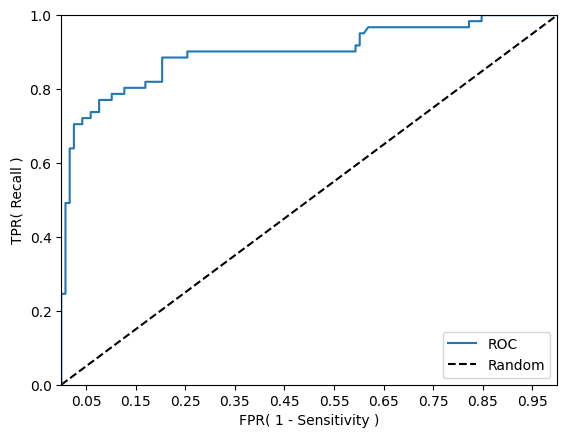

In [31]:
#5.2 이에 대한 시각화
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

def roc_curve_plot(y_test, pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환받음.
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
    
    # ROC 곡선을 그래프 곡선으로 그림.
    plt.plot(fprs, tprs, label='ROC')
    # 가운데 대각선 직선을 그림.
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    
    # FPR X 축의 Scale을 0.1 단위로 변경, X, Y축 명 설정 등
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1); plt.ylim(0, 1)
    plt.xlabel('FPR( 1 - Sensitivity )'); plt.ylabel('TPR( Recall )')
    plt.legend()
    plt.show()

roc_curve_plot(y_test, pred_proba[:, 1])

In [32]:
#5.3 ROC AUC 값
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:,1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8987


In [33]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

# 4장. 분류

# 1. 분류의 개요

### 1.1 지도학습
  1. 회귀 : 지금까지 배운 내용
  2. 분류 : 학습 데이터로 주어진 데이터의 피처와 레이블값을 머신러닝 알고르짐을 학습해 모델을 생성 > 이를 통해 새로운 데이터 값이 주어졌을 때 미지의 레이블 값을 예측
     - 즉, 기존 데이터가 어떤 레이블에 속하는지 패턴을 알고리즘으로 인지한 뒤에 새롭게 관측된 데이터에 대한 레이블을 판별

### 1.2 앙상블
- 서로 다른/같은 알고리즘을 결합, 기본 알고리즘으로 보통 결정 트리를 사용
1. 배깅: ex. 랜덤 포레스트 
2. 부스팅: ex. 그래디언트 부스팅(성능은 좋지만 시간이 오래 걸림) > XgBoost, LightGBM(성능, 시간 모두 좋음)
3. 스태킹: 앙상블의 앙상블 ex. XgBoost, LightGBM

### 1.3 결정트리
1. (+) 데이터 스케일링이나 정규화 등의 사전 가곡의 영향이 적음
2. (-) 구조에 따라서 과적합이 발생
3. 여러 개의 약한 학습기(결정트리)를 결합해 확률적 보완과 오류가 발생한 부분에 대한 가중치를 계속 업데이트하면서 예측 성능을 향상

# 2. 결정 트리

### 2.0 결정 트리
1. 규칙 노드
2. 리프 노드
3. 서브 트리
> **가능한 적게 규칙 노드를 만들기 => 정보 균일도가 높은 데이터 세트를 선택**
    - 정보 균일도 측정 방법: 엔트로피를 이용한 정보 이득 지수와 지니 계수

추가설명
- 적은 질문으로 정답 도달: 한 번의 분할로 데이터가 'A 집단'과 'B 집단'으로 완벽하게 나뉜다면(균일도 극대화), 더 이상 트리를 아래로 뻗어 나갈 필요가 없습니다. 즉, 노드 수가 줄어듭니다.

- 정보 이득(Information Gain) 극대화: 결정트리는 분할 전보다 분할 후에 엔트로피(혼잡도)가 얼마나 감소했는지를 측정합니다. 균일도가 높은 방향으로 데이터를 쪼갤수록 정보 이득이 커지며, 이는 곧 효율적인 규칙임을 의미합니다.

### 2.1 결정 트리 모델의 특징

#### 2.1.1 결정 트리의 장/단점

1. 결정 트리의 장점
- 쉽다, 직관적이다
- 피처의 스케일링이나 정규화 등의 사전 가공 영향도가 크지 않음

2. 결정 트리의 단점
- 과적합으로 알고리즘 성능이 떨어진다
- 이를 극복하기 위해 트리의 크기를 사전에 제한하는 튜닝이 필요하다

### 2.2 결정 트리 파라미터

### 2.3 결정 트리 모델의 시각화

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# DecisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156)

# 붓꽃 데이터를 로딩하고, 학습과 테스트 데이터 세트로 분리
iris_data=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=11)

# DecisionTreeClassifier 학습
dt_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,156
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [2]:
from sklearn.tree import export_graphviz

# export_graphviz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names, feature_names=iris_data.feature_names, impurity=True, filled=True)

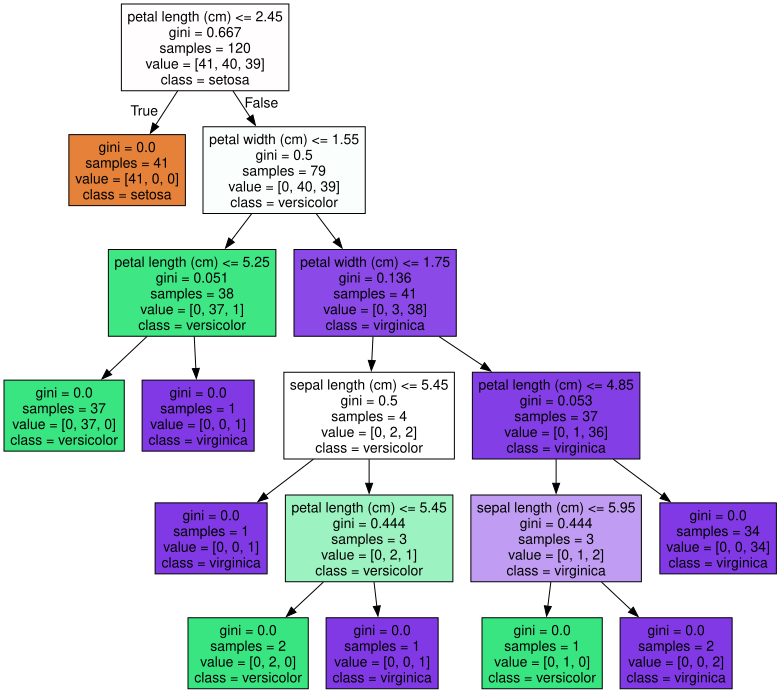

In [3]:
import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 주피터 노트북상에서 시각화
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

### 2.3.1 피처의 중요한 역할 지표 (규칙 노드의 개수를 줄여주는 친구)

Feature importances:
[0.025 0.    0.555 0.42 ]
sepal length (cm) : 0.025
sepal width (cm) : 0.000
petal length (cm) : 0.555
petal width (cm) : 0.420


<Axes: >

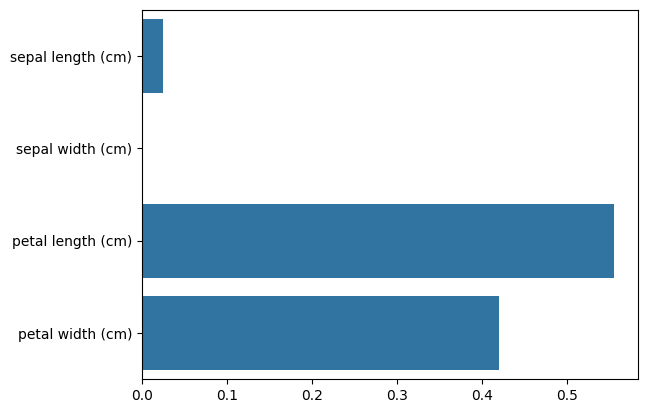

In [6]:
import seaborn as sns
import numpy as np
%matplotlib inline

# feature importance 추출
print("Feature importances:\n{0}".format(np.round(dt_clf.feature_importances_,3)))

# feature별 importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf. feature_importances_):
    print('{0} : {1:.3f}'.format(name,value))

# feature importance를 column 별로 시각화하기
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_boundary(model, X, y):
    fig, ax = plt.subplots()
    
    # 학습 데이터 산점도 그리기
    ax.scatter(X[:, 0], X[:, 1], c=y, s=25, cmap='rainbow', edgecolor='k',
               clim=(y.min(), y.max()), zorder=3)
    ax.axis('tight')
    ax.axis('off')
    xlim_start, xlim_end = ax.get_xlim()
    ylim_start, ylim_end = ax.get_ylim()
    
    # 모델 학습
    model.fit(X, y)
    
    # 결정 경계를 시각화하기 위해 메시그리드 생성
    xx, yy = np.meshgrid(np.linspace(xlim_start, xlim_end, num=200),
                         np.linspace(ylim_start, ylim_end, num=200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    # 등고선(Contour)을 이용하여 결정 경계 시각화
    n_classes = len(np.unique(y))
    contours = ax.contourf(xx, yy, Z, alpha=0.3,
                           levels=np.arange(n_classes + 1) - 0.5,
                           cmap='rainbow', clim=(y.min(), y.max()),
                           zorder=1)
    
    ax.set(xlim=(xlim_start, xlim_end), ylim=(ylim_start, ylim_end))

### 2.4 결정 트리 과적합 (Overfitting)
- 이상치까지 분류하려다 보니 경계가 상당히 복잡하게 나옴
- 이것을 min_samples_leaf=6으로 6개 이하의 데이터는 리프 노드를 생성하도록 함

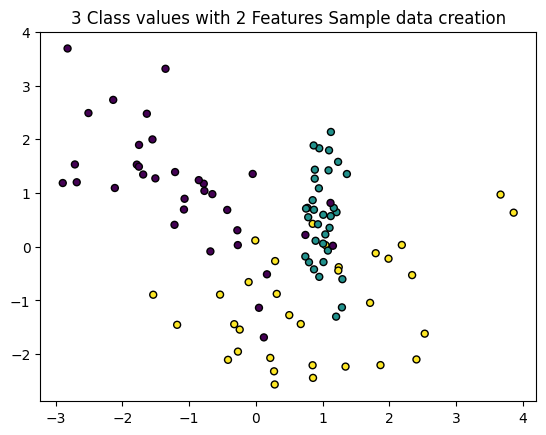

In [10]:
#2.4.1 피처 데이터 세트와 클래스 레이블 데이터 세트

from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data creation")

# 2차원 시각화를 위해서 피처는 2개, 클래스는 3가지 유형의 분류 샘플 데이터 생성
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2, n_classes=3, n_clusters_per_class=1, random_state=0)

# 그래프 형태로 2개의 피처로 2차원 좌표 시각화, 각 클래스 값은 다른 색깔로 표시됨
plt.scatter(X_features[:,0],X_features[:,1],marker='o',c=y_labels, s=25, edgecolor='k')

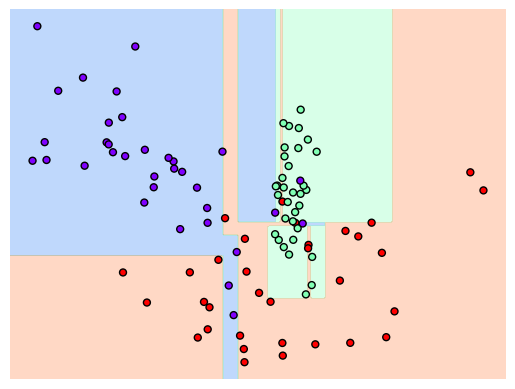

In [11]:
# 2.4.2 앞서 데이터 세트의 경계 구분
from sklearn.tree import DecisionTreeClassifier 

#특정한 트리 생성 제약 없는 결정 트리의 학습과 결정 경계 시각화
dt_clf = DecisionTreeClassifier().fit(X_features,y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

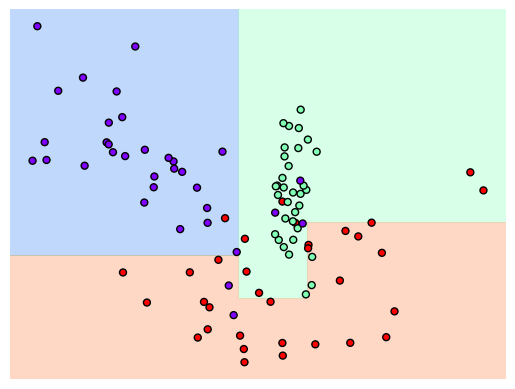

In [12]:
#min_samples_leaf=6으로 트리 생성 조건을 제약한 결정 경계 시각화
dt_clf = DecisionTreeClassifier(min_samples_leaf=6).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

### 2.5 결정 트리 실습 - 사용자 행동 인식 데이터 세트

In [2]:
#1. 데이터 불러오기

import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline 

#feature.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 있음. 이를 DataFrame으로 로드
feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                              header=None, names=['column_index','column_name'])

#피처명 index를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:,1].values.tolist()
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [3]:
#2. 중복 확인
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index']>1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [4]:
#3. 전처리1

def get_new_feature_namedf(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby ('column_name'). cumcount(),columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df. reset_index(), feature_dupdf, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x: x[0]+'_'+str(x[1]) if x[1]>0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

In [5]:
#4. 전처리2. tran/test 나누기

import pandas as pd

# [필수] 중복 피처명 해결을 위한 사전 함수
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
        lambda x: x[0] + '_' + str(x[1]) if x[1] > 0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

# [메인] 데이터셋 로드 함수
def get_human_dataset():
    # 1. 피처명 파일 로드 및 중복 제거
    feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+', 
                                  header=None, names=['column_index', 'column_name'])
    
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # 데이터프레임의 컬럼명으로 쓰기 위해 리스트로 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 2. 학습/테스트 피처 데이터 로드 (sep='\s+' 주의)
    X_train = pd.read_csv('./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
    X_test = pd.read_csv('./human_activity/test/X_test.txt', sep='\s+', names=feature_name)
    
    # 3. 학습/테스트 레이블(정답) 데이터 로드
    y_train = pd.read_csv('./human_activity/train/y_train.txt', sep='\s+', 
                          header=None, names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt', sep='\s+', 
                         header=None, names=['action'])
    
    # 로드된 데이터프레임들을 반환
    return X_train, X_test, y_train, y_test

# 함수 실행 및 데이터 할당 (함수 밖에서 호출해야 함)
X_train, X_test, y_train, y_test = get_human_dataset()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23972\3837987399.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lambda x: x[0] + '_' + str(x[1]) if x[1] > 0 else x[0], axis=1)


In [6]:
#5 print

print('## 학습 피처 데이터셋 info()')
print(X_train.info())

## 학습 피처 데이터셋 info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB
None


In [7]:
#6. 분포도

print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


In [8]:
#7. DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 예제 반복 시마다 동일한 예측 결과 도출을 위해 random_state 설정
dt_clf = DecisionTreeClassifier(random_state=156)

# 학습 시 fit() 메서드를 사용하며, 피처 데이터는 X_train입니다.
dt_clf.fit(X_train, y_train)

# 예측 수행
pred = dt_clf.predict(X_test)

# 정확도 측정 (포맷팅 소수점 .4f로 수정)
accuracy = accuracy_score(y_test, pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

# DecisionTreeClassifier의 하이퍼 파라미터 추출 (\n으로 개행 수정)
print('DecisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DecisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


In [9]:
#8. Tree 깊이에 따른 정확도1
from sklearn.model_selection import GridSearchCV
# 하이퍼 파라미터 설정
params = {'max_depth' : [6, 8, 10, 12, 16, 20, 24]}
# GridSearchCV 객체 생성 
grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
# 학습 수행
grid_cv.fit(X_train, y_train)
# 결과 출력 
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치: 0.8512
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 10}


In [10]:
#9. Tree 깊이에 따른 정확도2
## 8일때 가장 높은 정확도, 즉 그냥 많이 분류한다고 성능이 좋아지지 않음
#GridSearchCV 객체의 cv_results_ 속성을 DataFrame으로 생성
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

#max_depth 파라미터 값과 그때의 테스트 세트, 학습 데이터 세트의 정확도 수치 추출
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.850791
1,8,0.851069
2,10,0.851209
3,12,0.844271
4,16,0.850255
5,20,0.850120
6,24,0.849168


In [14]:
#10. 별도의 테스트 데이터 세트에서의 결정 트리 정확도1
max_depths = [ 6, 8, 10, 12, 16, 20, 24]
# max depth 값을 변화시키면서 그때마다 학습과 테스트 세트에서의 예측 성능 측정
for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, random_state=156)
    dt_clf. fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    print('max_depth = {0} 정확도: {1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도: 0.8558
max_depth = 8 정확도: 0.8707
max_depth = 10 정확도: 0.8673
max_depth = 12 정확도: 0.8646
max_depth = 16 정확도: 0.8575
max_depth = 20 정확도: 0.8548
max_depth = 24 정확도: 0.8548


In [17]:
#11. max_depth와 min_samples_split을 변경하며 정확도 성능 튜닝

params = {
    'max_depth': [8, 12, 16, 20],      
    'min_samples_split': [16, 24], 
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)

print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


In [18]:
#12. 앞선 튜닝을 바탕으로 테스트 데이터 세트로 예측 수행
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)
print('결정 트리 예측 정확도:{0:.4f}'.format(accuracy))

결정 트리 예측 정확도:0.8717


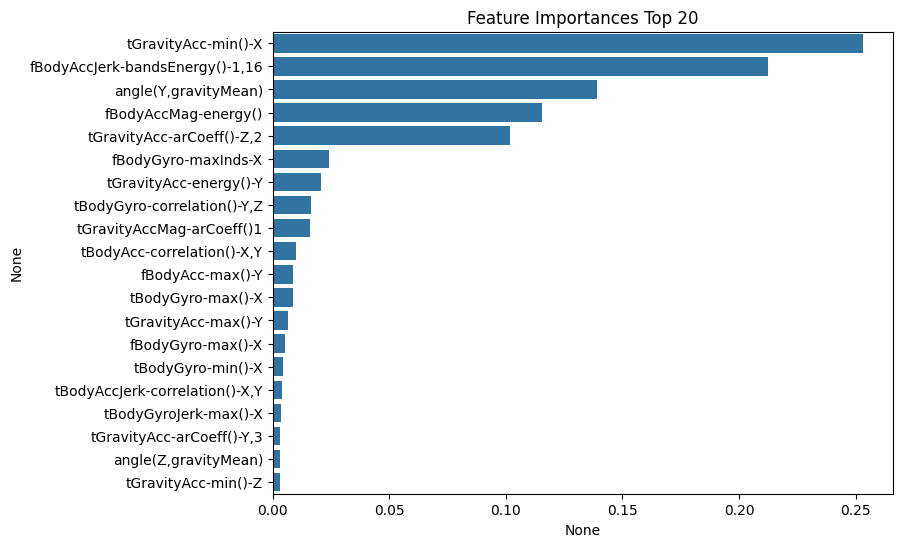

In [20]:
#13. 결과  시각화
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 속성명 앞뒤 공백 제거 및 오타 수정
ftr_importances_values = best_df_clf.feature_importances_
# 2. Series 변환 (index 접근 시 공백 제거)
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
# 3. 정렬 시 ascending=False (하이픈 '-'을 등호 '='로 수정)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8, 6))
plt.title('Feature Importances Top 20')
# 4. x-ftr_top20 -> x=ftr_top20 (하이픈 '-'을 등호 '='로 수정)
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

# 8. 회귀트리

In [1]:
#8.1 랜덤포레스트로 회귀 트리 :  보스턴 주택 가격 예측
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# 사이킷런 1.2 버전부터 load_boston이 삭제되었으므로, 원본 URL에서 직접 데이터를 가져옵니다.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# 특성 이름 직접 정의
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# 데이터프레임 생성 및 타겟 변수 추가
bostonDF = pd.DataFrame(data, columns=feature_names)
bostonDF['PRICE'] = target

# 피처 데이터 세트와 타겟 데이터 세트 분리
y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

# 랜덤 포레스트 회귀 모델 생성 (결정 트리 개수 1000개)
rf = RandomForestRegressor(random_state=0, n_estimators=1000)

# cross_val_score를 이용해 5 폴드 교차 검증 수행 
# scoring="neg_mean_squared_error"는 음수 MSE 값을 반환함에 유의
neg_mse_scores = cross_val_score(rf, X_data, y_target, scoring="neg_mean_squared_error", cv=5)

# 음수 MSE 점수에 -1을 곱한 후 루트를 씌워 RMSE(Root Mean Squared Error) 계산
rmse_scores = np.sqrt(-1 * neg_mse_scores)

# 전체 교차 검증 세트의 평균 RMSE 계산
avg_rmse = np.mean(rmse_scores)

# 최종 결과 출력
print(' 5 교차 검증의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 교차 검증의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 교차 검증의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 교차 검증의 개별 Negative MSE scores:  [ -7.88 -13.14 -20.57 -46.23 -18.88]
 5 교차 검증의 개별 RMSE scores :  [2.81 3.63 4.54 6.8  4.34]
 5 교차 검증의 평균 RMSE : 4.423 


In [2]:
#8.2 결정 트리, GBM, XGBoost, LightGBM 이용
def get_model_cv_prediction(model, X_data, y_target):
    # cross_val_score를 이용해 5 폴드 교차 검증 수행
    # scoring 인자에 정확한 지표 명칭("neg_mean_squared_error")을 전달합니다.
    neg_mse_scores = cross_val_score(model, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
    
    # 음수 MSE에 -1을 곱한 후 루트를 씌워 실제 RMSE 값을 산출합니다.
    rmse_scores = np.sqrt(-1 * neg_mse_scores)
    
    # 5개의 폴드 세트에서 계산된 RMSE의 평균을 구합니다.
    avg_rmse = np.mean(rmse_scores)
    
    # 모델의 클래스 명칭을 동적으로 가져와서 결과를 출력합니다.
    # model.__class__.__name__을 통해 "RandomForestRegressor" 등의 이름을 추출합니다.
    print('#### ', model.__class__.__name__, ' ####')
    print(' 5 교차 검증의 평균 RMSE : {0:.3f} '.format(avg_rmse))

In [5]:
# LightGBM과 XGBoost의 출력 메시지를 무시하도록 옵션을 수정합니다.

# XGBoost: verbosity=0으로 설정하여 메시지 출력 안 함
xgb_reg = XGBRegressor(n_estimators=1000, verbosity=0)

# LightGBM: verbose=-1로 설정하여 메시지 출력 안 함
# (최신 버전에서는 학습 시 'verbose' 인자를 따로 주거나 생성 시 넣을 수 있습니다)
lgb_reg = LGBMRegressor(n_estimators=1000, verbose=-1)

# 나머지 모델은 그대로 유지
dt_reg = DecisionTreeRegressor(random_state=0, max_depth=4)
rf_reg = RandomForestRegressor(random_state=0, n_estimators=1000)
gb_reg = GradientBoostingRegressor(random_state=0, n_estimators=1000)

# 모델 리스트 업데이트
models = [dt_reg, rf_reg, gb_reg, xgb_reg, lgb_reg]

# 다시 반복문 실행
for model in models:
    get_model_cv_prediction(model, X_data, y_target)

####  DecisionTreeRegressor  ####
 5 교차 검증의 평균 RMSE : 5.978 
####  RandomForestRegressor  ####
 5 교차 검증의 평균 RMSE : 4.423 
####  GradientBoostingRegressor  ####
 5 교차 검증의 평균 RMSE : 4.269 
####  XGBRegressor  ####
 5 교차 검증의 평균 RMSE : 4.959 
####  LGBMRegressor  ####
 5 교차 검증의 평균 RMSE : 4.646 


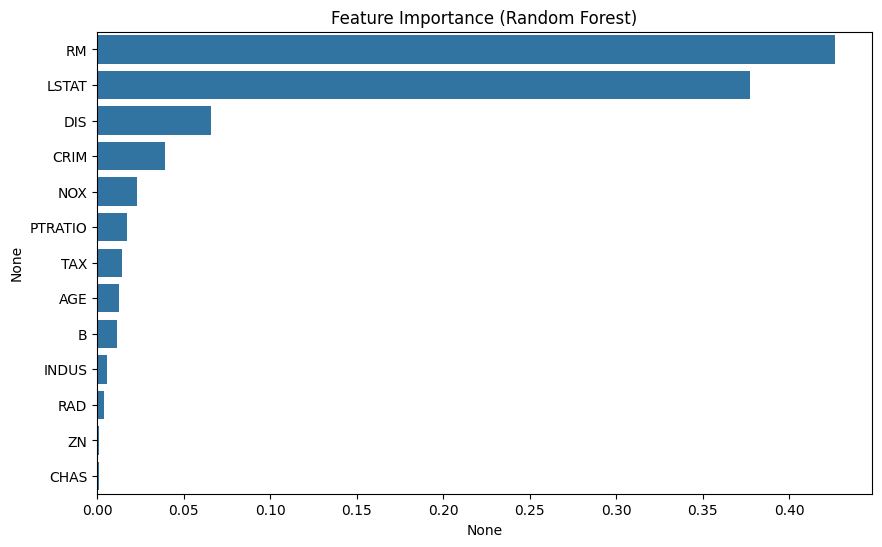

In [6]:
# 8.3 회귀 트리는 선형 회귀와 달라 회귀 계수를 제공하는 coef_ 속성이 없음
# 다만, feature_importances_를 이용해 피처별 중요도를 알려줌
import seaborn as sns
import matplotlib.pyplot as plt
# 주피터 노트북 내에 그래프를 바로 그리기 위한 매직 명령어
%matplotlib inline

# 모델 학습 (앞서 정의한 rf_reg 사용)
rf_reg = RandomForestRegressor(n_estimators=1000, random_state=0)
rf_reg.fit(X_data, y_target)

# 피처 중요도를 Series로 변환
# rf_reg.feature_importances_는 각 피처의 중요도 수치를 배열로 반환합니다.
feature_series = pd.Series(data=rf_reg.feature_importances_, index=X_data.columns)

# 중요도 내림차순으로 정렬
feature_series = feature_series.sort_values(ascending=False)

# 그래프 크기 설정 및 바 차트 출력
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_series, y=feature_series.index)
plt.title('Feature Importance (Random Forest)')
plt.show()

### 8.4 회귀 트리와 선형 회귀의 비교 : 시각화
: 결정 트리의 하이퍼 파라미터인 max_depth의 크기를 변화시키면서 어떻게 회귀 트리 예측선이 변화하는지 

(100, 2)


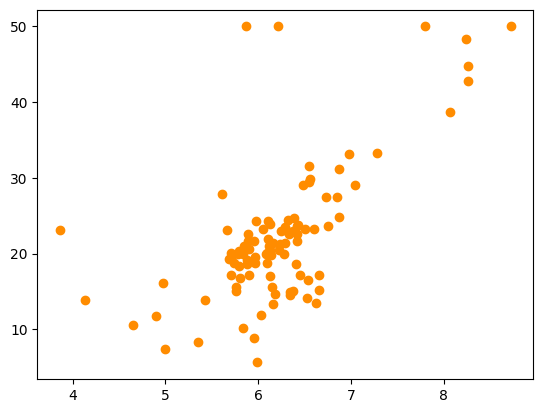

In [11]:
# price와 가장 밀접한 양의 상관관계를 가지는 RM 칼럼만 이용
bostonDF_sample = bostonDF[['RM','PRICE']]
bostonDF_sample = bostonDF_sample.sample(n=100, random_state=0)
print(bostonDF_sample.shape)
plt.figure()
plt.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")

In [9]:
#선형 회귀와 트리 회귀를 mat_depth를 각각 2,7로 해서 학습
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# 선형 회귀와 결정 트리 기반의 Regressor 생성
lr_reg = LinearRegression()
rf_reg2 = DecisionTreeRegressor(max_depth=2)
rf_reg7 = DecisionTreeRegressor(max_depth=7)

# 시각화를 위해 피처는 RM(방 개수)만, 타겟은 PRICE 추출
# 학습을 위해 100개의 샘플만 추출하여 bostonDF_sample을 만듭니다.
bostonDF_sample = bostonDF[['RM', 'PRICE']].sample(n=100, random_state=0)
X_feature = bostonDF_sample['RM'].values.reshape(-1, 1)
y_target = bostonDF_sample['PRICE'].values.reshape(-1, 1)

# 실제 예측을 적용할 테스트용 데이터를 4.5에서 8.5까지 100개 생성
X_test = np.arange(4.5, 8.5, 0.04).reshape(-1, 1)

# 학습 수행
lr_reg.fit(X_feature, y_target)
rf_reg2.fit(X_feature, y_target)
rf_reg7.fit(X_feature, y_target)

# 예측 수행
pred_lr = lr_reg.predict(X_test)
pred_rf2 = rf_reg2.predict(X_test)
pred_rf7 = rf_reg7.predict(X_test)

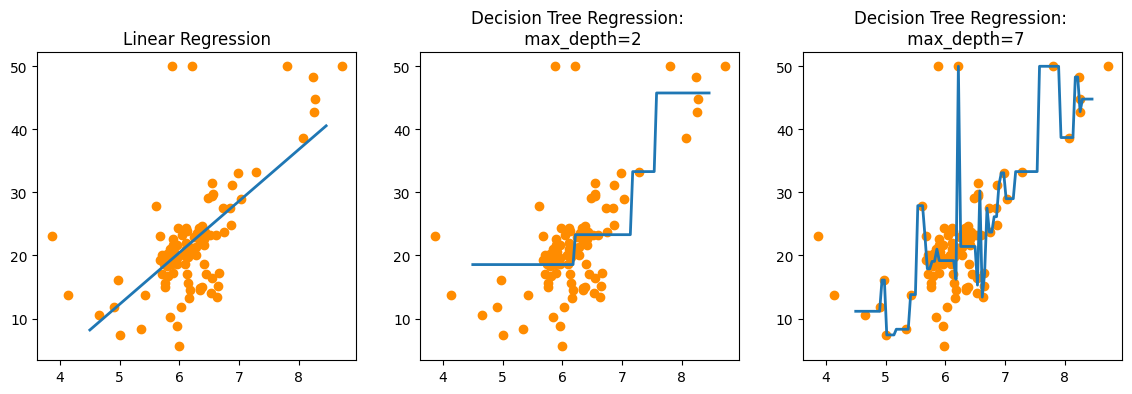

In [10]:
import matplotlib.pyplot as plt

# 3개의 서브플롯을 생성하여 각각의 모델 예측 결과를 비교합니다.
fig, (ax1, ax2, ax3) = plt.subplots(figsize=(14, 4), ncols=3)

# 1. 선형 회귀 시각화
# 선형 회귀는 데이터의 전체적인 흐름을 하나의 직선으로 나타냅니다.
ax1.set_title('Linear Regression')
ax1.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax1.plot(X_test, pred_lr, label="linear", linewidth=2)

# 2. DecisionTreeRegressor (max_depth=2) 시각화
# 트리의 깊이가 얕으면 데이터를 듬성듬성하게 구분하여 '계단 모양'이 단순합니다.
ax2.set_title('Decision Tree Regression: \n max_depth=2')
ax2.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax2.plot(X_test, pred_rf2, label="max_depth:2", linewidth=2)

# 3. DecisionTreeRegressor (max_depth=7) 시각화
# 트리가 깊어지면 학습 데이터의 개별 특성(노이즈 포함)에 너무 집착하여 예측선이 매우 복잡해집니다.
ax3.set_title('Decision Tree Regression: \n max_depth=7')
ax3.scatter(bostonDF_sample.RM, bostonDF_sample.PRICE, c="darkorange")
ax3.plot(X_test, pred_rf7, label="max_depth:7", linewidth=2)

plt.show()

- 선형 회귀: 직선
- 회귀 트리: 분할되는 데이터 지점에 따라 브랜치를 만들면서 계단 형태로 회귀선을 생성 
> max_depth가 7인 경우: 이상치 데이터도 학습하면서 복잡한 계단 형태의 회귀선을 생성 : 과적합